In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.cluster import MeanShift, estimate_bandwidth

In [2]:
address = ""
all_files = glob.glob(address+'images/*.png')
img_row_size = 67
img_col_size = 48
img_size = img_row_size*img_col_size

In [3]:
img_data = []
for i in range(len(all_files)):
    img_color = cv.imread(all_files[i], cv.IMREAD_COLOR)
    img_color = cv.resize(cv.cvtColor(img_color, cv.COLOR_BGR2RGB), (img_col_size, img_row_size))[0:40,15:40,:]
    R = img_color[:, :, 0].astype(int)
    G = img_color[:, :, 1].astype(int)
    B = img_color[:, :, 2].astype(int)
    weighted_image = 1.0 * R - 1.0 * G - 1.0 * B
    weighted_image[weighted_image < 0] = 0

    img_data += [weighted_image]
    #img_gray = cv.imread(all_files[i], cv.IMREAD_GRAYSCALE)
    #img_data += [cv.resize(img_gray, (img_col_size, img_row_size))[0:40,15:40]]

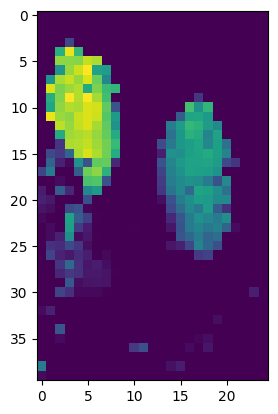

In [4]:
# Key part of the code for forming the rules

eg = 2

X = []
for i in range(len(img_data[eg])):
    for j in range(len(img_data[eg][0])):
        for k in range(int((img_data[eg][i][j])/50)):
            X += [[j+np.random.randn(1)[0]/5,i+np.random.randn(1)[0]/5]]
X = np.array(X)

plt.imshow(img_data[eg])

Number of estimated clusters: 3
Cluster centers:
 [[ 4.46828585 10.10842047]
 [16.80925812 16.36677637]
 [-0.11495541 38.012292  ]]


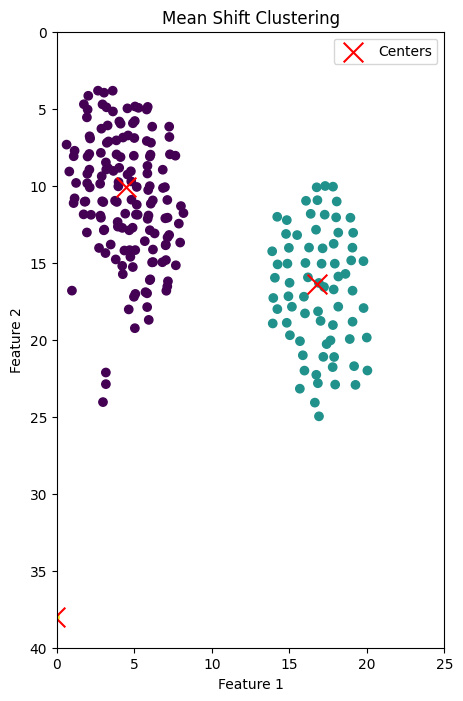

In [5]:
# Bandwidth Estimation
# bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=len(X))
bandwidth = 6

# Performing MeanShift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

# Finding the Cluster Centers
cluster_centers = ms.cluster_centers_
labels = ms.labels_

# Finding the Number of Clusters
n_clusters_ = len(np.unique(labels))

print(f"Number of estimated clusters: {n_clusters_}")
print("Cluster centers:\n", cluster_centers)

# Visualization
plt.figure(figsize=(5, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='red', s=200, label='Centers')
plt.xlim([0,25])
plt.ylim([0,40])
plt.title('Mean Shift Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.gca().invert_yaxis()
plt.show()